## ANN - Análisis

Se interpretan los vecinos de `c_busqueda_ann.ipynb`: qué entidades y regiones tienen procesos muy parecidos, si la similitud es mayor dentro de una entidad, y cuánto varía el **monto** entre procesos casi iguales (P3)

### Imports

In [1]:
import os, socket, time, shutil
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pyspark.sql import SparkSession, Window, functions as F

%matplotlib inline
plt.rcParams.update({"figure.dpi": 100, "axes.grid": True, "grid.alpha": .3})
pd.set_option("display.max_colwidth", 80); pd.set_option("display.width", 200)

### Utilidades

- Constantes

In [ ]:
proyecto = Path.cwd()
while not (proyecto / "docker-compose.yml").exists() and proyecto != proyecto.parent:
    proyecto = proyecto.parent
final_dir = proyecto / "data" / "final"
vectores_dir = proyecto / "03_ANN" / "temp" / "a_vectores_tfidf" / "vectores"
centroides_dir = proyecto / "03_ANN" / "temp" / "b_indice_ivf" / "centroides"
listas_dir = proyecto / "03_ANN" / "temp" / "b_indice_ivf" / "listas"
vecinos_dir = proyecto / "03_ANN" / "temp" / "c_busqueda_ann" / "vecinos"

- Funciones

Parámetros y funciones compartidas de `03_ANN/funciones.ipynb`

In [ ]:
ruta_funciones = str(proyecto / "03_ANN" / "funciones.ipynb")
%run $ruta_funciones

- Spark

In [3]:
spark_master = os.environ.get("spark_master", "local[*]")

builder = (SparkSession.builder
           .appName("ann-analisis")
           .master(spark_master)
           .config("spark.driver.memory",   os.environ.get("SPARK_DRIVER_MEMORY", "4g"))     # 4g (vs 2g en 05): firmas/vectores y joins por pares pesan más que canastas
           .config("spark.executor.memory", os.environ.get("SPARK_EXECUTOR_MEMORY", "4g"))
           .config("spark.sql.shuffle.partitions", "24")                                   # ~231k filas: 24 tareas bastan, las 200 por defecto quedarían casi vacías
           .config("spark.sql.autoBroadcastJoinThreshold", "-1")                           # sin broadcast automático: los parquets descomprimidos saturaban el driver
           .config("spark.ui.showConsoleProgress", "false")
           .config("spark.sql.session.timeZone", "America/Lima"))

if spark_master.startswith("spark://"):
    builder = (builder.config("spark.driver.host", socket.gethostname())
                      .config("spark.driver.bindAddress", "0.0.0.0"))

spark = builder.getOrCreate()
spark.sparkContext.setLogLevel("ERROR")

### Verificación del cluster

In [4]:
sc = spark.sparkContext
estado = sc._jsc.sc().getExecutorMemoryStatus()
print(f"Master        : {sc.master}")
print(f"Executors     : {estado.size() - 1}")
print(f"Cores totales : {sc.defaultParallelism}")
print(f"Memoria driver: {sc._jvm.java.lang.Runtime.getRuntime().maxMemory() / 1024**3:.1f} GB")
print("UI del job    : http://localhost:4040")

Master        : spark://spark-master:7077
Executors     : 0
Cores totales : 2
Memoria driver: 3.0 GB
UI del job    : http://localhost:4040


---
### 1. Carga de vecinos

In [5]:
assert vecinos_dir.exists(), f"No se encuentra {vecinos_dir}; corre c_busqueda_ann.ipynb"
vecinos = spark.read.parquet(str(vecinos_dir)).cache()
n_v = vecinos.count(); n_q = vecinos.select("ocid_q").distinct().count()
print(f"Vecinos: {n_v:,} | consultas: {n_q:,} | K = {K} | umbral 'muy parecidos': coseno ≥ {UMBRAL_SIM}")
vecinos.select(F.expr("percentile_approx(cos_sim, array(0.1, 0.5, 0.9))").alias("coseno p10/p50/p90")).show(truncate=False)
muy = vecinos.where(F.col("cos_sim") >= UMBRAL_SIM).cache()
print(f"Pares muy parecidos: {muy.count():,} ({muy.count() / n_v:.1%} de los vecinos)")

Vecinos: 198,600 | consultas: 19,860 | K = 10 | umbral 'muy parecidos': coseno ≥ 0.8
+------------------------+
|coseno p10/p50/p90      |
+------------------------+
|[0.2923, 0.5092, 0.9019]|
+------------------------+

Pares muy parecidos: 32,158 (16.2% de los vecinos)


### 2. Misma entidad vs. distinta entidad

¿La similitud es mayor dentro de una entidad? Se compara el coseno de los vecinos según sean de la misma entidad o de otra

In [6]:
vecinos.groupBy("misma_entidad").agg(F.count("*").alias("vecinos"), F.round(F.avg("cos_sim"), 3).alias("coseno_prom"),
                                      F.round(F.avg((F.col("cos_sim") >= UMBRAL_SIM).cast("int")), 3).alias("frac_muy_parecidos")).show()
vecinos.groupBy("misma_region").agg(F.count("*").alias("vecinos"), F.round(F.avg("cos_sim"), 3).alias("coseno_prom"),
                                     F.round(F.avg((F.col("cos_sim") >= UMBRAL_SIM).cast("int")), 3).alias("frac_muy_parecidos")).show()

+-------------+-------+-----------+------------------+
|misma_entidad|vecinos|coseno_prom|frac_muy_parecidos|
+-------------+-------+-----------+------------------+
|        false| 106042|      0.446|              0.03|
|         true|  92558|      0.673|             0.313|
+-------------+-------+-----------+------------------+

+------------+-------+-----------+------------------+
|misma_region|vecinos|coseno_prom|frac_muy_parecidos|
+------------+-------+-----------+------------------+
|       false|  79869|      0.446|             0.029|
|        true| 118731|      0.624|             0.251|
+------------+-------+-----------+------------------+



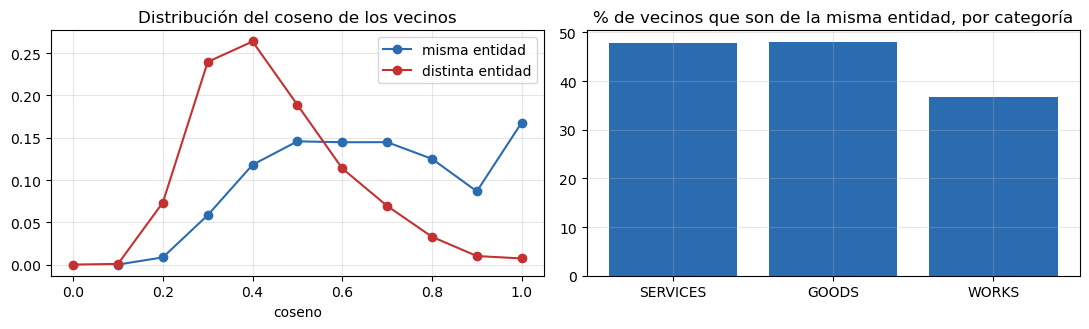

In [7]:
d = vecinos.select("misma_entidad", F.round("cos_sim", 1).alias("c")).groupBy("misma_entidad", "c").count().toPandas()
fig, ax = plt.subplots(1, 2, figsize=(11, 3.4))
for ok, col, lab in [(True, "#2b6cb0", "misma entidad"), (False, "#c53030", "distinta entidad")]:
    s = d[d.misma_entidad == ok].sort_values("c"); ax[0].plot(s["c"], s["count"] / s["count"].sum(), marker="o", color=col, label=lab)
ax[0].set_title("Distribución del coseno de los vecinos"); ax[0].set_xlabel("coseno"); ax[0].legend()
cat = vecinos.groupBy("categoria").agg(F.avg(F.col("misma_entidad").cast("int")).alias("frac")).toPandas()
ax[1].bar(cat["categoria"], cat["frac"] * 100, color="#2b6cb0"); ax[1].set_title("% de vecinos que son de la misma entidad, por categoría")
plt.tight_layout(); plt.show()

- Misma entidad: coseno promedio 0.67 y 31% muy parecidos; distinta entidad: 0.45 y 3%

- Con regiones pasa lo mismo (0.62 vs. 0.45)

- Cada entidad se parece sobre todo a sí misma

### 3. Entidades con procesos muy parecidos

Dentro de la misma entidad (compras repetidas) y entre entidades distintas (el mismo objeto comprado por varias)

In [8]:
print("Dentro de la misma entidad:")
(muy.where("misma_entidad").groupBy("entidad_q").agg(F.countDistinct("ocid_q").alias("procesos"), F.count("*").alias("pares"), F.round(F.avg("cos_sim"), 3).alias("coseno"))
    .orderBy(F.desc("pares")).show(10, truncate=45))
print("Entre entidades distintas (pares de entidades):")
(muy.where("NOT misma_entidad").withColumn("e1", F.least("entidad_q", "entidad_v")).withColumn("e2", F.greatest("entidad_q", "entidad_v"))
    .groupBy("e1", "e2").agg(F.count("*").alias("pares"), F.round(F.avg("cos_sim"), 3).alias("coseno")).orderBy(F.desc("pares")).show(10, truncate=40))

Dentro de la misma entidad:
+---------------------------------------------+--------+-----+------+
|                                    entidad_q|procesos|pares|coseno|
+---------------------------------------------+--------+-----+------+
|ORGANISMO DE EVALUACION Y FISCALIZACION AM...|     345| 3251| 0.985|
|       GOBIERNO REGIONAL DE PUNO SEDE CENTRAL|     187|  955| 0.893|
|   GOBIERNO REGIONAL DE AYACUCHO SEDE CENTRAL|     145|  690| 0.877|
|                      SEGURO SOCIAL DE  SALUD|     240|  503| 0.925|
|                             EJERCITO PERUANO|     144|  365| 0.908|
|PROGRAMA DE DESARROLLO PRODUCTIVO AGRARIO ...|      72|  301| 0.911|
|   GOBIERNO REGIONAL DE AREQUIPA SEDE CENTRAL|      77|  293| 0.883|
|                      PETROLEOS DEL PERU S.A.|     106|  265|  0.95|
|ORGANISMO SUPERVISOR DE LAS CONTRATACIONES...|      31|  230| 0.927|
|           MUNICIPALIDAD DISTRITAL DE PICHARI|      60|  213| 0.903|
+---------------------------------------------+--------+-----+

- Dentro de la misma entidad lidera OEFA (345 procesos, 3,251 pares, coseno 0.985), el mismo caso de `02_Similitud`

- Entre entidades distintas las coincidencias son pocas y suelen ser instituciones relacionadas; el caso más alto es un instituto nacional de investigación con OEFA (31 pares con coseno 1.0, la misma plantilla de texto)

### 4. Regiones

Qué regiones concentran procesos muy parecidos, y entre qué pares de regiones se repite el mismo objeto de compra

+----------------+-----+-----------------+-------------+------------------+
|        region_q|pares|frac_misma_region|vecinos_total|frac_muy_parecidos|
+----------------+-----+-----------------+-------------+------------------+
|            LIMA|10977|             0.96|        54980|               0.2|
|            PUNO| 1298|            0.992|         4440|             0.292|
|        HUAMANGA| 1178|            0.952|         4690|             0.251|
|           CUSCO| 1072|            0.863|         6340|             0.169|
|   LA CONVENCION| 1014|             0.96|         5880|             0.172|
|        AREQUIPA|  979|             0.91|         6050|             0.162|
|        HUANCAYO|  613|            0.954|         4210|             0.146|
|        TRUJILLO|  566|            0.862|         4090|             0.138|
|CORONEL PORTILLO|  550|            0.916|         2540|             0.217|
|  MARISCAL NIETO|  509|            0.957|         2520|             0.202|
|          C

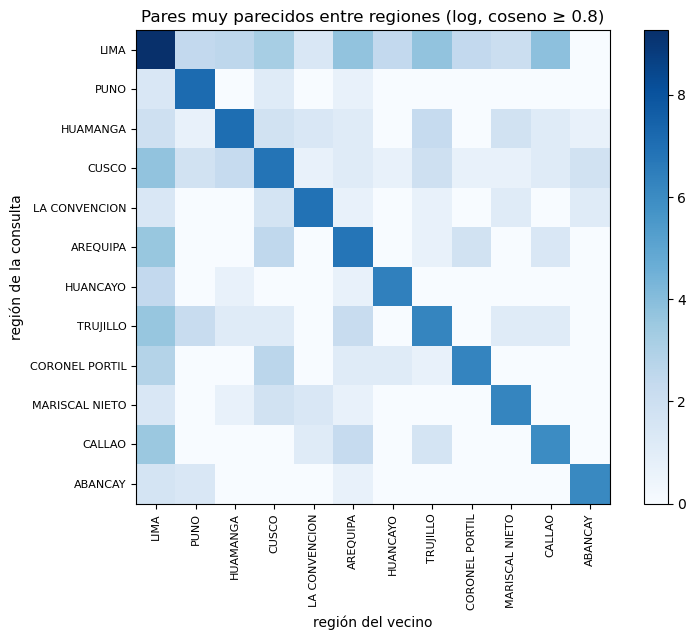

In [9]:
reg = (muy.groupBy("region_q").agg(F.count("*").alias("pares"), F.round(F.avg(F.col("misma_region").cast("int")), 3).alias("frac_misma_region"))
          .join(vecinos.groupBy("region_q").agg(F.count("*").alias("vecinos_total")), "region_q")
          .withColumn("frac_muy_parecidos", F.round(F.col("pares") / F.col("vecinos_total"), 3)).orderBy(F.desc("pares")))
reg.show(12, truncate=30)

# 12 regiones con más pares: la matriz sigue siendo legible
top_reg = [r_["region_q"] for r_ in reg.where("region_q IS NOT NULL").limit(12).collect()]
mat = (muy.where(F.col("region_q").isin(top_reg) & F.col("region_v").isin(top_reg))
          .groupBy("region_q").pivot("region_v", top_reg).count().fillna(0).toPandas().set_index("region_q").reindex(top_reg))
fig, ax = plt.subplots(figsize=(8, 6.5))
im = ax.imshow(np.log1p(mat.values), cmap="Blues")
ax.set_xticks(range(len(top_reg))); ax.set_xticklabels([r_[:14] for r_ in top_reg], rotation=90, fontsize=8)
ax.set_yticks(range(len(top_reg))); ax.set_yticklabels([r_[:14] for r_ in top_reg], fontsize=8)
ax.set_xlabel("región del vecino"); ax.set_ylabel("región de la consulta"); ax.set_title(f"Pares muy parecidos entre regiones (log, coseno ≥ {UMBRAL_SIM})"); ax.grid(False)
plt.colorbar(im, ax=ax, fraction=.04); plt.tight_layout(); plt.show()

- La diagonal = similitud dentro de la misma región; fuera de la diagonal = el mismo objeto comprado en regiones distintas, que es lo que permite comparar precios

- Entre el 86% y el 99% de los pares muy parecidos de cada región son con la misma región

### 5. Variación del monto entre procesos muy parecidos (P3)

- Para cada consulta con vecinos muy parecidos y con monto: `ratio = monto_consulta / mediana(monto de sus vecinos)`. En log₂: 0 = paga lo mismo, +1 = el doble, −1 = la mitad

- Es una **señal**, no prueba de sobreprecio: el monto es total (no unitario) y los textos parecidos pueden esconder cantidades o especificaciones distintas

In [10]:
base = muy.where(F.col("monto_final_q").isNotNull() & F.col("monto_final_v").isNotNull() & (F.col("monto_final_q") > 0) & (F.col("monto_final_v") > 0))
var = (base.groupBy("ocid_q", "entidad_q", "region_q", "categoria", "monto_final_q")
           .agg(F.count("*").alias("vecinos"), F.expr("percentile_approx(monto_final_v, 0.5)").alias("monto_mediana_vecinos"),
                F.min("monto_final_v").alias("monto_min_v"), F.max("monto_final_v").alias("monto_max_v"))
           .withColumn("ratio", F.col("monto_final_q") / F.col("monto_mediana_vecinos"))
           .withColumn("log2_ratio", F.log2("ratio")).cache())
n_var = var.count()
print(f"Consultas con vecinos muy parecidos y monto comparable: {n_var:,}")
var.select(F.expr("percentile_approx(log2_ratio, array(0.05, 0.25, 0.5, 0.75, 0.95))").alias("log2(ratio) p5/p25/p50/p75/p95")).show(truncate=False)
# cortes de 2x y 5x: el doble y el quíntuple de lo que pagan los vecinos, fáciles de leer
print(f"Pagan ≥ 2x la mediana de sus vecinos: {var.where('ratio >= 2').count():,} ({var.where('ratio >= 2').count() / n_var:.1%}) | "
      f"≥ 5x: {var.where('ratio >= 5').count():,} ({var.where('ratio >= 5').count() / n_var:.1%})")

Consultas con vecinos muy parecidos y monto comparable: 10,299
+----------------------------------------------------------------------------------------+
|log2(ratio) p5/p25/p50/p75/p95                                                          |
+----------------------------------------------------------------------------------------+
|[-1.494257523985903, -0.15200309344504997, 0.0, 0.32192809488736235, 1.8329718637846029]|
+----------------------------------------------------------------------------------------+

Pagan ≥ 2x la mediana de sus vecinos: 1,213 (11.8%) | ≥ 5x: 326 (3.2%)


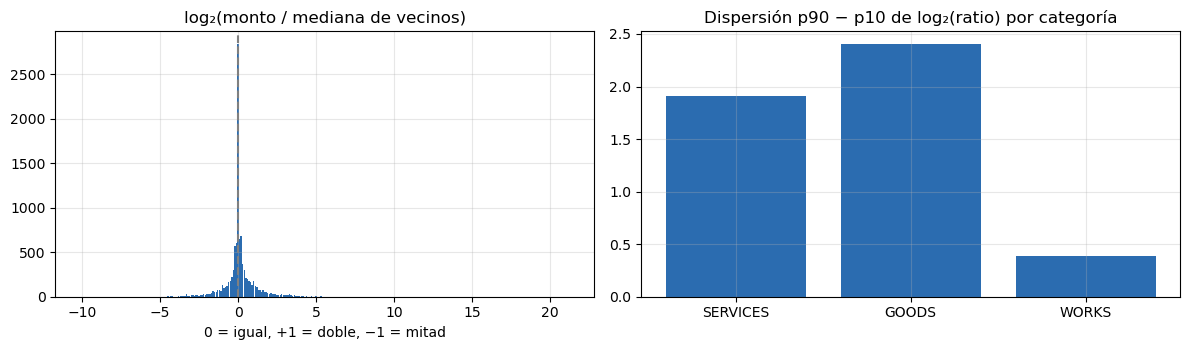

In [11]:
h = var.select(F.round("log2_ratio", 1).alias("l")).groupBy("l").count().orderBy("l").toPandas()
por_cat = var.groupBy("categoria").agg(F.expr("percentile_approx(log2_ratio, 0.5)").alias("p50"), F.expr("percentile_approx(log2_ratio, 0.9)").alias("p90"),
                                       F.expr("percentile_approx(log2_ratio, 0.1)").alias("p10")).toPandas()
fig, ax = plt.subplots(1, 2, figsize=(12, 3.6))
ax[0].bar(h["l"], h["count"], width=.09, color="#2b6cb0"); ax[0].axvline(0, color="gray", ls="--"); ax[0].set_title("log₂(monto / mediana de vecinos)"); ax[0].set_xlabel("0 = igual, +1 = doble, −1 = mitad")
x = np.arange(len(por_cat)); ax[1].bar(x, por_cat["p90"] - por_cat["p10"], color="#2b6cb0"); ax[1].set_xticks(x); ax[1].set_xticklabels(por_cat["categoria"])
ax[1].set_title("Dispersión p90 − p10 de log₂(ratio) por categoría"); plt.tight_layout(); plt.show()

- 10,299 consultas con monto comparable; la mediana paga lo mismo que sus vecinos (log₂ = 0)

- La mitad central está entre 0.90x y 1.25x, y los extremos (5%–95%) entre 0.36x y 3.6x

- El 11.8% paga 2 veces o más y el 3.2%, 5 veces o más

### 6. Dónde se paga más: regiones y entidades

Mediana de `log2_ratio` por región y por entidad (≥ `MIN_CONS` consultas). Positivo = esa región/entidad paga por encima de lo que pagan otras por lo mismo

In [12]:
MIN_CONS = 20              # mínimo de consultas por región/entidad para que la mediana no dependa de 2–3 casos
reg_var = (var.groupBy("region_q").agg(F.count("*").alias("consultas"), F.round(F.expr("percentile_approx(log2_ratio, 0.5)"), 3).alias("log2_ratio_mediana"),
                                       F.round(F.avg((F.col("ratio") >= 2).cast("int")), 3).alias("frac_paga_2x"))
              .where(f"consultas >= {MIN_CONS}").orderBy(F.desc("log2_ratio_mediana")))
reg_var.show(12, truncate=30)
ent_var = (var.groupBy("entidad_q").agg(F.count("*").alias("consultas"), F.round(F.expr("percentile_approx(log2_ratio, 0.5)"), 3).alias("log2_ratio_mediana"),
                                        F.round(F.avg((F.col("ratio") >= 2).cast("int")), 3).alias("frac_paga_2x"))
              .where(f"consultas >= {MIN_CONS}").orderBy(F.desc("log2_ratio_mediana")))
ent_var.show(10, truncate=45)

+-------------+---------+------------------+------------+
|     region_q|consultas|log2_ratio_mediana|frac_paga_2x|
+-------------+---------+------------------+------------+
|     AZANGARO|       23|             0.174|       0.174|
|     URUBAMBA|       31|             0.163|       0.097|
|        ISLAY|       27|             0.152|       0.111|
|  PAUCARTAMBO|       22|             0.146|       0.091|
|      CANCHIS|       34|             0.142|       0.118|
|LEONCIO PRADO|       34|              0.08|       0.059|
|     MORROPON|       38|             0.059|       0.158|
|      ATALAYA|       21|             0.057|         0.0|
|       HUARAZ|       99|             0.047|       0.071|
|   SAN MARTIN|       47|             0.036|        0.17|
|      ABANCAY|      136|             0.028|       0.169|
|JORGE BASADRE|       55|             0.027|       0.164|
+-------------+---------+------------------+------------+
only showing top 12 rows

+---------------------------------------------

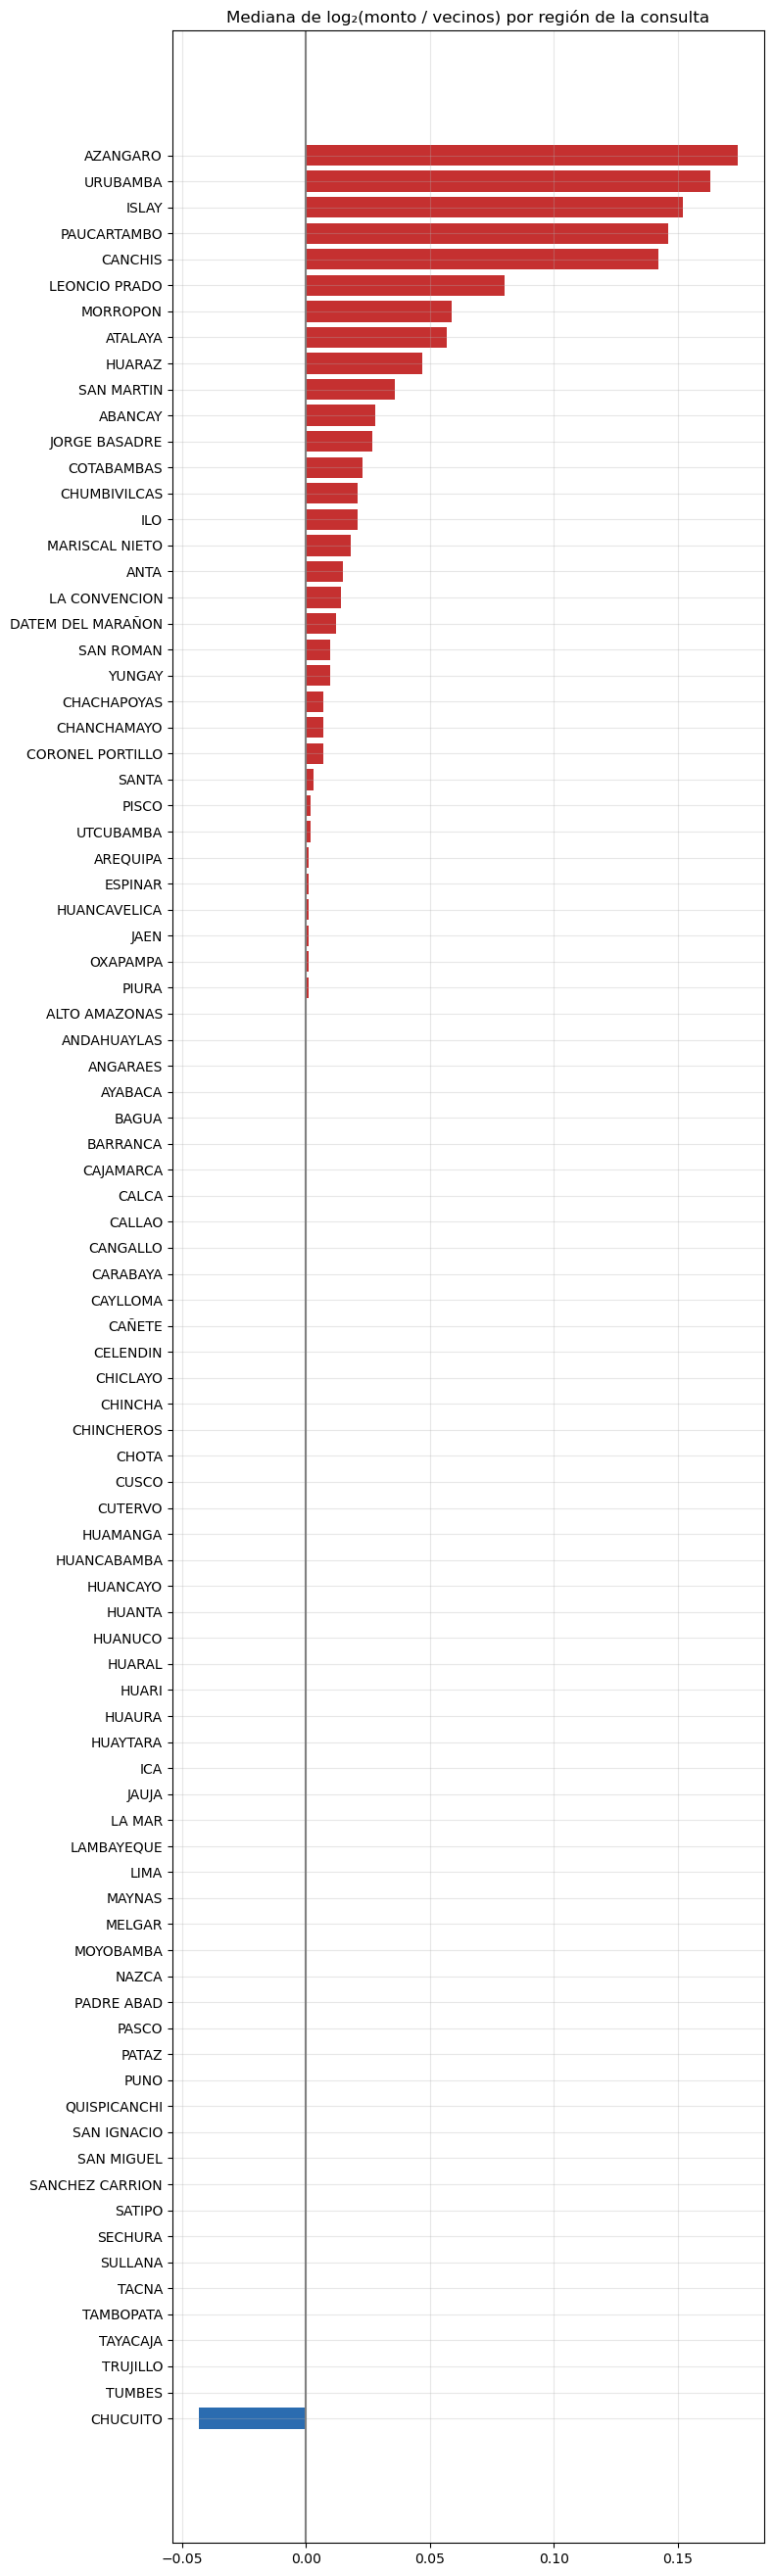

In [13]:
rp = reg_var.toPandas().iloc[::-1]
if len(rp):
    fig, ax = plt.subplots(figsize=(8, max(3, .3 * len(rp))))
    ax.barh(rp["region_q"].str[:25], rp["log2_ratio_mediana"], color=["#c53030" if v > 0 else "#2b6cb0" for v in rp["log2_ratio_mediana"]])
    ax.axvline(0, color="gray"); ax.set_title("Mediana de log₂(monto / vecinos) por región de la consulta"); plt.tight_layout(); plt.show()

- Ninguna región paga sistemáticamente más: la mediana más alta es Azángaro (log₂ 0.17 ≈ 1.13x)

- Entidades por encima de sus vecinos: Banco de la Nación (≈ 1.45x) y la Municipalidad de Challhuahuacho (≈ 1.18x)

### 7. Ejemplos: mismo objeto, regiones distintas, montos distintos

In [14]:
desc = spark.read.parquet(str(final_dir)).select("ocid", "descripcion")
ej = (base.where("NOT misma_region").withColumn("ratio", F.greatest(F.col("monto_final_q") / F.col("monto_final_v"), F.col("monto_final_v") / F.col("monto_final_q")))
          .orderBy(F.desc("cos_sim"), F.desc("ratio")).where("ratio >= 2").limit(3)
          .join(desc.withColumnRenamed("ocid", "ocid_q").withColumnRenamed("descripcion", "desc_q"), "ocid_q")
          .join(desc.withColumnRenamed("ocid", "ocid_v").withColumnRenamed("descripcion", "desc_v"), "ocid_v").collect())
for r_ in ej:
    print(f"\ncoseno {r_['cos_sim']} | ratio {r_['ratio']:.1f}x")
    print(f"  [{r_['region_q']}] {r_['entidad_q'][:40]} — S/ {r_['monto_final_q']:,.0f}\n    {r_['desc_q'][:160]}")
    print(f"  [{r_['region_v']}] {r_['entidad_v'][:40]} — S/ {r_['monto_final_v']:,.0f}\n    {r_['desc_v'][:160]}")


coseno 1.0 | ratio 84.2x
  [TUMBES] GOBIERNO REGIONAL DE TUMBES - HOSPITAL R — S/ 40,500
    ADQUISICION DE INMUNOGLOBULINA HUMANA NORMAL 10G/100 mL INY 50 ML
  [LIMA] CENTRO NACIONAL DE ABASTECIMIENTO DE REC — S/ 3,408,600
    ADQUISICIÓN DE INMUNOGLOBULINA HUMANA NORMAL 5 G/100 ML INY - 2024

coseno 1.0 | ratio 43.5x
  [TRUJILLO] GOBIERNO REGIONAL DE LA LIBERTAD-INSTITU — S/ 71,600
    ADQUISICION DE MESA ELECTROHIDRAULICA PARA OPERACION QUIRURGICA
  [LIMA] HOSPITAL DE APOYO DEPARTAMENTAL MARIA AU — S/ 3,112,000
    ADQUISICIÓN DE MESA ELECTROHIDRAULICA PARA OPERACIÓN QUIRURGICA

coseno 1.0 | ratio 47.8x
  [CAMANA] MUNICIPALIDAD PROVINCIAL DE CAMANA — S/ 164,366
    ADQUISICIÓN DE INSUMOS PARA EL PROGRAMA DEL VASO DE LECHE PERIODO 2025
  [LIMA] MUNICIPALIDAD DISTRITAL DE SAN MARTIN DE — S/ 7,850,865
    ADQUISICION DE INSUMOS PARA EL PROGRAMA VASO DE LECHE - PERIODO 2025


- Los extremos son el mismo producto en **cantidades** distintas: inmunoglobulina 84x (CENARES compra para todo el país), vaso de leche 48x, mesa quirúrgica 43x

- El monto es total, no unitario

### 8. Experimento: umbral de "muy parecidos" (`UMBRAL_SIM`)

Se repite el análisis de montos con coseno ≥ 0.70, 0.80 y 0.90 para ver cuánto dependen las conclusiones del umbral

In [ ]:
EXP_UMBRAL_SIM = [0.70, 0.80, 0.90]   # más laxo, actual y más estricto

def resumen_umbral(u):
    m = vecinos.where(F.col("cos_sim") >= u)
    con_monto = m.where(F.col("monto_final_q").isNotNull() & F.col("monto_final_v").isNotNull() &
                        (F.col("monto_final_q") > 0) & (F.col("monto_final_v") > 0))
    v = (con_monto.groupBy("ocid_q", "monto_final_q").agg(F.expr("percentile_approx(monto_final_v, 0.5)").alias("mediana_v"))
                  .withColumn("ratio", F.col("monto_final_q") / F.col("mediana_v")))
    rp = m.agg(F.count("*").alias("pares"), F.avg(F.col("misma_entidad").cast("int")).alias("misma_entidad"),
               F.avg(F.col("misma_region").cast("int")).alias("misma_region")).first()
    rv = v.agg(F.count("*").alias("consultas"), F.expr("percentile_approx(ratio, array(0.25, 0.75))").alias("p"),
               F.avg((F.col("ratio") >= 2).cast("int")).alias("f2"), F.avg((F.col("ratio") >= 5).cast("int")).alias("f5")).first()
    return {"UMBRAL_SIM": u, "pares": rp["pares"], "frac_vecinos": round(rp["pares"] / n_v, 3),
            "frac_misma_entidad": round(rp["misma_entidad"], 3), "frac_misma_region": round(rp["misma_region"], 3),
            "consultas_con_monto": rv["consultas"], "ratio_p25": round(rv["p"][0], 2), "ratio_p75": round(rv["p"][1], 2),
            "frac_paga_2x": round(rv["f2"], 3), "frac_paga_5x": round(rv["f5"], 3)}

tabla_us = pd.DataFrame([resumen_umbral(u_) for u_ in EXP_UMBRAL_SIM])
tabla_us

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(10, 3.5))
x = tabla_us["UMBRAL_SIM"].astype(str)
ax[0].bar(x, tabla_us["consultas_con_monto"], color="#2b6cb0"); ax[0].set_title("Consultas con monto comparable"); ax[0].set_xlabel("UMBRAL_SIM")
w = .35; i = np.arange(len(x))
ax[1].bar(i - w / 2, tabla_us["frac_paga_2x"] * 100, w, label="≥ 2x"); ax[1].bar(i + w / 2, tabla_us["frac_paga_5x"] * 100, w, label="≥ 5x")
ax[1].set_xticks(i); ax[1].set_xticklabels(x); ax[1].set_xlabel("UMBRAL_SIM"); ax[1].set_title("% de consultas que pagan más que sus vecinos"); ax[1].legend()
plt.tight_layout(); plt.show()

- Qué mirar: la fila 0.80 debe repetir los números de la sección 5 (10,299 consultas, 11.8% paga ≥ 2x)

- Con un umbral más laxo entran vecinos menos parecidos: más consultas, pero se esperan más casos ≥ 2x porque se comparan objetos distintos

- Si el % que paga ≥ 2x cambia poco entre 0.80 y 0.90, la conclusión no depende del umbral

### 9. Salidas

```python
vectores = spark.read.parquet("03_ANN/temp/a_vectores_tfidf/vectores")   # TF-IDF normalizado por proceso
listas   = spark.read.parquet("03_ANN/temp/b_indice_ivf/listas")         # lista IVF de cada proceso
vecinos  = spark.read.parquet("03_ANN/temp/c_busqueda_ann/vecinos")      # K vecinos aproximados por consulta
```

In [15]:
for d_ in [vectores_dir, centroides_dir, listas_dir, vecinos_dir]:
    df_ = spark.read.parquet(str(d_))
    print(f"{str(d_.relative_to(proyecto)):45s} {df_.count():>9,} filas x {len(df_.columns):>2} columnas")

data/p3/vectores         231,171 filas x 16 columnas
data/p3/centroides           300 filas x  2 columnas
data/p3/listas           231,171 filas x  4 columnas
data/p3/vecinos          198,600 filas x 14 columnas


---
### 10. Síntesis

- **Una diferencia de monto no es sobreprecio:** los casos extremos son el mismo producto en cantidades distintas

- **El texto alcanza para encontrar compras parecidas, no para fijar precios de referencia:** haría falta la cantidad o el precio unitario por ítem

- **La variación existe caso por caso, no por región:** los que pagan 2x o 5x sobre sus vecinos son una lista para revisar, no una conclusión

- El recall de 69% implica que algunos vecinos verdaderos no aparecen, y la muestra es de ~20 mil consultas, no de los 231 mil procesos

---
### 11. Cerrar sesión

In [16]:
spark.stop()